# CS4305 Artificial Intelligence — Lab 4
## LISP and Expert System Shells

**What you will learn today**
1. Write LISP expressions in **prefix notation**
2. Work with **lists** using `car`, `cdr` and `cons`
3. Define **functions**, **conditions** and **recursion**
4. See why "code is data" makes LISP good for AI
5. Understand an **expert system shell** and use a real one (**CLIPS**)

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----

print('Diagram tools ready')

---
## Part 0: Install LISP
We install **SBCL**, a free Common Lisp system. We will write each program into a `.lisp` file with `%%writefile`, then run it with `!sbcl --script`.

In [ ]:
# ===== Install a LISP system (SBCL = Steel Bank Common Lisp). Run once, ~30 seconds =====
!apt-get install -y sbcl > /dev/null 2>&1
!sbcl --version

---
## Part 1: Prefix notation — operator first
In maths we write `(2 + 3) × 4`. In LISP we write `(* (+ 2 3) 4)`. **Everything is a list**, and the **first item is the operator**. LISP always works out the **innermost list first**.

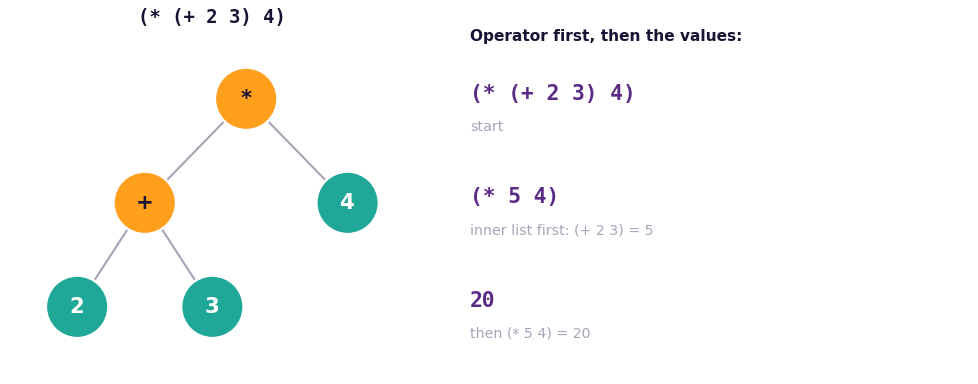

In [ ]:
#@title 📊 Visual explanation: how LISP reads (* (+ 2 3) 4)
def fig_expr_tree():
    children = {"*": ["+", "4"], "+": ["2", "3"]}
    pos = tree_layout(children, "*", gap=1.3)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1, 1.1]})
    draw_graph(ax, pos, [("*", "+"), ("*", "4"), ("+", "2"), ("+", "3")],
               colors={"*": ORANGE, "+": ORANGE, "2": TEAL, "3": TEAL, "4": TEAL}, r=0.3, fs=18)
    ax.set_title("(* (+ 2 3) 4)", fontsize=16, family="monospace", fontweight="bold", color=DARK)
    ax2.axis("off")
    steps = [("(* (+ 2 3) 4)", "start"), ("(* 5 4)", "inner list first: (+ 2 3) = 5"), ("20", "then (* 5 4) = 20")]
    for i, (e, t) in enumerate(steps):
        y = 0.8 - i * 0.3
        ax2.text(0.02, y, e, fontsize=18, family="monospace", fontweight="bold", color=PURPLE, transform=ax2.transAxes)
        ax2.text(0.02, y - 0.09, t, fontsize=12, color=GREY, transform=ax2.transAxes)
    ax2.text(0.02, 0.97, "Operator first, then the values:", fontsize=13, color=DARK, transform=ax2.transAxes, fontweight="bold")
    finish(fig)
    return fig

fig_expr_tree()
plt.show()

In [ ]:
%%writefile prefix.lisp
;;; In LISP the OPERATOR comes first, then the values:  (operator value value ...)
(format t "(+ 2 3)         = ~a~%" (+ 2 3))
(format t "(* (+ 2 3) 4)   = ~a~%" (* (+ 2 3) 4))
(format t "(- 10 4 1)      = ~a~%" (- 10 4 1))
(format t "(max 7 21 3)    = ~a~%" (max 7 21 3))
(format t "(sqrt 144)      = ~a~%" (sqrt 144))

In [ ]:
!sbcl --script prefix.lisp

---
## Part 2: Lists — car, cdr, cons
- `car` → the **first** element
- `cdr` → **everything except** the first element
- `cons` → **add** an element to the front

The quote `'` tells LISP: *"this is data, don't try to run it."*

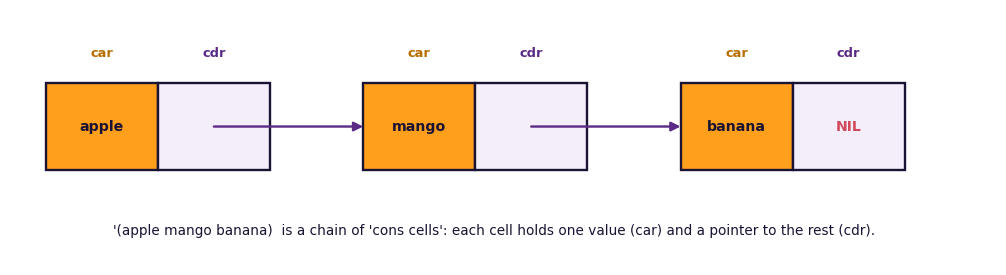

In [ ]:
#@title 📊 Visual explanation: how a LIST is stored in memory
def fig_cons_cells():
    fig, ax = plt.subplots(figsize=(12, 3.4))
    vals = ["apple", "mango", "banana"]
    for i, v in enumerate(vals):
        x = 0.4 + i * 3.4
        ax.add_patch(Rectangle((x, 1.0), 1.2, 0.8, fc=ORANGE, ec=DARK, lw=2))
        ax.add_patch(Rectangle((x + 1.2, 1.0), 1.2, 0.8, fc=LIGHT, ec=DARK, lw=2))
        ax.text(x + 0.6, 1.4, v, ha="center", va="center", fontsize=12, fontweight="bold", color=DARK)
        ax.text(x + 0.6, 2.05, "car", ha="center", fontsize=11, color="#B86E00", fontweight="bold")
        ax.text(x + 1.8, 2.05, "cdr", ha="center", fontsize=11, color=PURPLE, fontweight="bold")
        if i < 2:
            arrow(ax, x + 1.8, 1.4, x + 3.4, 1.4, color=PURPLE)
        else:
            ax.text(x + 1.8, 1.4, "NIL", ha="center", va="center", fontsize=12, fontweight="bold", color=ROSE)
    ax.text(5.2, 0.4, "'(apple mango banana)  is a chain of 'cons cells': each cell holds one value (car) and a pointer to the rest (cdr).",
            ha="center", fontsize=11.5, color=DARK)
    ax.set_xlim(0, 10.6); ax.set_ylim(0.1, 2.5); ax.axis("off")
    finish(fig)
    return fig

fig_cons_cells()
plt.show()

In [ ]:
%%writefile lists.lisp
(defparameter fruits '(apple mango banana))     ; the quote ' means "this is data, don't run it"

(format t "fruits                 = ~a~%" fruits)
(format t "(car fruits)           = ~a~%" (car fruits))            ; first element
(format t "(cdr fruits)           = ~a~%" (cdr fruits))            ; the rest
(format t "(car (cdr fruits))     = ~a~%" (car (cdr fruits)))      ; second element
(format t "(cons 'orange fruits)  = ~a~%" (cons 'orange fruits))   ; add at the front
(format t "(length fruits)        = ~a~%" (length fruits))
(format t "(reverse fruits)       = ~a~%" (reverse fruits))
(format t "(append '(1 2) '(3 4)) = ~a~%" (append '(1 2) '(3 4)))

In [ ]:
!sbcl --script lists.lisp

---
## Part 3: Functions and conditions
- `(defun name (inputs) body)` defines a function
- `(if condition then else)` chooses between two options
- `(cond (test1 result1) (test2 result2) ... (t otherwise))` checks many options in order

In [ ]:
%%writefile functions.lisp
;;; ----- defun = define a function -----
(defun square (x) (* x x))
(format t "Square of 7 = ~a~%" (square 7))

;;; ----- if: (if condition then else) -----
(defun pass-or-fail (marks)
  (if (>= marks 50) "Pass" "Fail"))
(format t "45 marks -> ~a~%" (pass-or-fail 45))

;;; ----- cond: many conditions, checked top to bottom -----
(defun grade (marks)
  (cond ((>= marks 85) 'A)
        ((>= marks 70) 'B)
        ((>= marks 50) 'C)
        (t 'F)))                    ; t means "otherwise"
(format t "Grade for 78 = ~a~%" (grade 78))

In [ ]:
!sbcl --script functions.lisp

---
## Part 4: Recursion
LISP programs love recursion: solve a **small** problem, and let the function call itself for the rest.

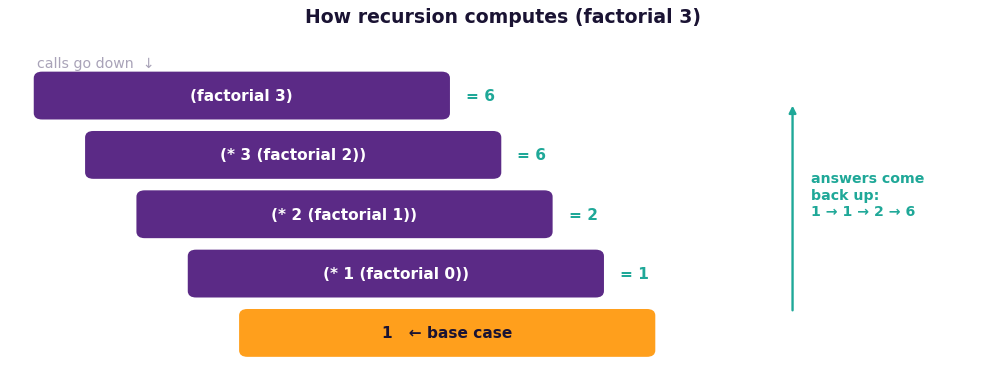

In [ ]:
#@title 📊 Visual explanation: how (factorial 3) is computed
def fig_factorial_stack():
    fig, ax = plt.subplots(figsize=(12, 4.6))
    calls = ["(factorial 3)", "(* 3 (factorial 2))", "(* 2 (factorial 1))", "(* 1 (factorial 0))", "1   ← base case"]
    rets = ["= 6", "= 6", "= 2", "= 1", ""]
    for i, c in enumerate(calls):
        x, y = 0.3 + i * 0.55, 4 - i * 0.85
        box(ax, x, y, 4.4, 0.62, c, fc=ORANGE if i == 4 else PURPLE, tc=DARK if i == 4 else WHITE, fs=13)
        if rets[i]:
            ax.text(x + 4.6, y + 0.31, rets[i], va="center", fontsize=13, fontweight="bold", color=TEAL)
    ax.text(0.3, 4.72, "calls go down  ↓", fontsize=12, color=GREY)
    ax.annotate("", xy=(8.4, 4.2), xytext=(8.4, 1.2), arrowprops=dict(arrowstyle="-|>", color=TEAL, lw=2))
    ax.text(8.6, 2.6, "answers come\nback up:\n1 → 1 → 2 → 6", fontsize=12, color=TEAL, fontweight="bold")
    ax.set_xlim(0, 10.6); ax.set_ylim(0.3, 5.0); ax.axis("off")
    finish(fig, "How recursion computes (factorial 3)")
    return fig

fig_factorial_stack()
plt.show()

In [ ]:
%%writefile recursion.lisp
(defun factorial (n)
  (if (= n 0)
      1                                   ; base case
      (* n (factorial (- n 1)))))         ; recursive case
(format t "5! = ~a~%" (factorial 5))

(defun my-length (lst)
  (if (null lst) 0 (+ 1 (my-length (cdr lst)))))
(format t "Length of (a b c d) = ~a~%" (my-length '(a b c d)))

(defun my-member (x lst)
  (cond ((null lst) nil)                  ; empty list: not found
        ((equal x (car lst)) t)           ; first element matches: found
        (t (my-member x (cdr lst)))))     ; otherwise search the rest
(format t "Is mango in the list? ~a~%" (my-member 'mango '(apple mango banana)))

In [ ]:
!sbcl --script recursion.lisp

---
## Part 5: Code is data (symbolic AI)
In LISP a program is also a list, so a program can **build and run other programs**. We can also attach **properties** to symbols to store knowledge. Watch the penguin answer carefully!

In [ ]:
%%writefile symbolic.lisp
;;; ----- Code is data: a list can be treated as a program -----
(defparameter expr '(+ 10 20 30))
(format t "The list ~a starts with the symbol ~a~%" expr (car expr))
(format t "Evaluating it gives ~a~%" (eval expr))

;;; ----- A tiny knowledge base using symbols and properties -----
(setf (get 'sparrow 'is-a) 'bird)
(setf (get 'penguin 'is-a) 'bird)
(setf (get 'bird 'can) 'fly)
(defun can-fly (animal)
  (eq (get (get animal 'is-a) 'can) 'fly))
(format t "Can a sparrow fly? ~a~%" (can-fly 'sparrow))
(format t "Can a penguin fly? ~a   <- WRONG! Our knowledge needs exceptions.~%" (can-fly 'penguin))

In [ ]:
!sbcl --script symbolic.lisp

---
## Part 6: Expert System Shells
An **expert system** = Knowledge Base + Inference Engine + User Interface.

A **shell** is an expert system with an **empty knowledge base**. The engine is ready-made; the expert only adds rules.

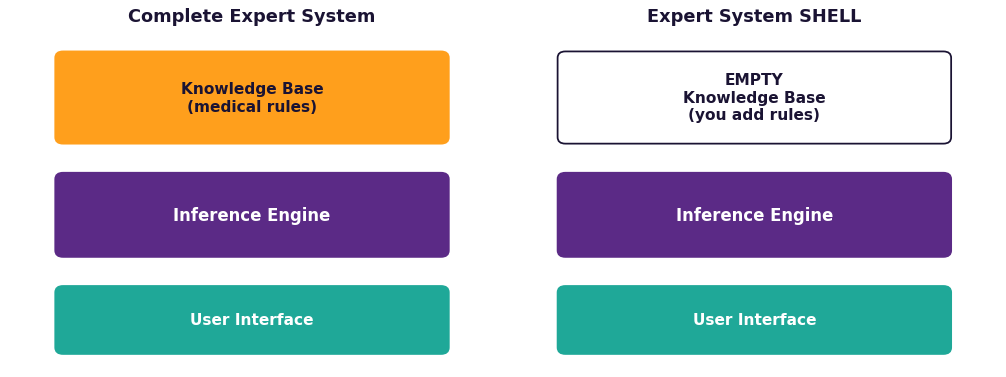

In [ ]:
#@title 📊 Visual explanation: a complete expert system vs a shell
def fig_shell():
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
    for ax, kb_fc, kb_text, title in [(a1, ORANGE, "Knowledge Base\n(medical rules)", "Complete Expert System"),
                                      (a2, WHITE, "EMPTY\nKnowledge Base\n(you add rules)", "Expert System SHELL")]:
        box(ax, 0.5, 2.6, 4, 1.1, kb_text, fc=kb_fc, tc=DARK, fs=13, ec=DARK if kb_fc == WHITE else None)
        box(ax, 0.5, 1.2, 4, 1.0, "Inference Engine", fc=PURPLE, fs=14)
        box(ax, 0.5, 0.0, 4, 0.8, "User Interface", fc=TEAL, fs=13)
        ax.set_title(title, fontsize=15, fontweight="bold", color=DARK)
        ax.set_xlim(0, 5); ax.set_ylim(-0.2, 4.0); ax.axis("off")
    finish(fig)
    return fig

fig_shell()
plt.show()

### 6a. Build a mini shell in Python
Our `MiniShell` has an inference engine (**forward chaining**: keep firing rules until nothing new is found) but **no rules** at the start.

In [ ]:
# ===== Part 2: Expert System Shell =====
# A SHELL = inference engine + interface, with an EMPTY knowledge base.
class MiniShell:
    def __init__(self, name):
        self.name = name
        self.rules = []                      # the knowledge base starts EMPTY

    def add_rule(self, conditions, conclusion):
        self.rules.append((set(conditions), conclusion))

    def run(self, facts):
        """Inference engine (forward chaining): keep firing rules until nothing new is learned."""
        facts, fired = set(facts), True
        print(f"[{self.name}] starting facts: {sorted(facts)}")
        while fired:
            fired = False
            for conds, concl in self.rules:
                if conds <= facts and concl not in facts:
                    print(f"   IF {' AND '.join(sorted(conds))}  THEN  {concl}")
                    facts.add(concl); fired = True
        return facts

print("Shell created. Rules in knowledge base:", len(MiniShell("test").rules))

### 6b. One shell, two experts
We fill the **same** shell with a doctor's rules and then with a mechanic's rules. The engine code does not change — only the knowledge does.

In [ ]:
# ===== The SAME shell used for two completely different experts =====
doctor = MiniShell("Doctor")
doctor.add_rule(["fever", "cough", "body_ache"], "flu")
doctor.add_rule(["fever", "joint_pain", "rash"], "dengue")
doctor.add_rule(["dengue"], "visit_hospital")
doctor.run(["fever", "joint_pain", "rash"])
print()

mechanic = MiniShell("Mechanic")
mechanic.add_rule(["engine_wont_start", "lights_dim"], "battery_weak")
mechanic.add_rule(["battery_weak"], "charge_or_replace_battery")
mechanic.add_rule(["engine_wont_start", "fuel_gauge_empty"], "no_fuel")
mechanic.run(["engine_wont_start", "lights_dim"])

### 6c. A real shell: CLIPS
**CLIPS** was built at NASA and is still used today. A CLIPS rule looks like:
```
(defrule name   conditions   =>   actions)
```
We use `clipspy`, the Python version of CLIPS.

In [ ]:
# ===== A real shell: CLIPS (developed at NASA). Install the Python version =====
!pip install -q clipspy

In [ ]:
import clips

env = clips.Environment()                    # an empty CLIPS shell

def say(*words):                             # lets CLIPS rules print in Colab
    print("".join(str(w) for w in words))
env.define_function(say)

# ---- We only ADD the knowledge (rules). The engine is already built into CLIPS. ----
env.build("""
(defrule flu
   (symptom fever) (symptom cough) (symptom body_ache)
   =>
   (say "Diagnosis: Flu. Advice: rest and drink fluids.")
   (assert (diagnosis flu)))""")
env.build("""
(defrule dengue
   (symptom fever) (symptom joint_pain) (symptom rash)
   =>
   (say "Diagnosis: Dengue suspected. Advice: get a blood test.")
   (assert (diagnosis dengue)))""")
env.build("""
(defrule serious
   (diagnosis dengue)
   =>
   (say "Warning: this may be serious - visit a hospital."))""")

for s in ["fever", "joint_pain", "rash"]:    # the patient's facts
    env.assert_string(f"(symptom {s})")

fired = env.run()
print("\nRules fired:", fired)
print("Facts now in memory:")
for f in env.facts():
    print("  ", f)

---
## 📝 Lab Tasks
1. Write a LISP function `(cube x)` and a function `(average a b)`.
2. Write a recursive LISP function `(sum-list lst)` that adds all numbers in a list.
3. Write `(second-last lst)` that returns the second-last element of a list.
4. Use `MiniShell` to build a third expert: a **career advisor** with at least 5 rules.
5. Add two new rules to the CLIPS example (e.g. *typhoid*, *malaria*) and test them with new symptoms.
6. **Think:** in Part 5, why was the penguin answer wrong? How could we fix our knowledge?